In [ ]:
from transformer_architecture_base import Transformer

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(DEVICE)

2.5.1
cuda


In [53]:
df = pd.read_csv("data/cleaned_dataset.csv")
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,179.426579,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,179.426579,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,211.382074,60.0,652230.0,33.93911,67.709953


In [54]:
df[df["Entity"] == "Somalia"]

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
2520,Somalia,2000,1.892501,0.4,93.28,0.23,0.0,0.00,0.000000,340.10217,11.22,490.000000,350.168162,25.0,637657.0,5.152149,46.199616
2521,Somalia,2001,4.504616,0.4,93.26,0.25,0.0,0.00,0.000000,332.43317,11.32,510.000000,350.168162,25.0,637657.0,5.152149,46.199616
2522,Somalia,2002,7.400000,0.5,92.58,0.26,0.0,0.00,0.000000,346.37854,11.39,569.999993,350.168162,25.0,637657.0,5.152149,46.199616
2523,Somalia,2003,9.708441,0.5,92.80,0.26,0.0,0.00,0.000000,334.05520,11.51,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2524,Somalia,2004,12.304850,0.6,93.00,0.26,0.0,0.00,0.000000,322.42703,11.48,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2525,Somalia,2005,14.900722,0.6,93.30,0.27,0.0,0.00,0.000000,314.66333,11.47,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2526,Somalia,2006,15.233786,0.7,93.47,0.28,0.0,0.00,0.000000,307.72528,11.60,579.999983,350.168162,25.0,637657.0,5.152149,46.199616
2527,Somalia,2007,20.100733,0.7,93.02,0.29,0.0,0.00,0.000000,302.79350,11.53,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2528,Somalia,2008,22.710230,0.8,93.37,0.30,0.0,0.00,0.000000,291.03380,11.74,620.000005,350.168162,25.0,637657.0,5.152149,46.199616
2529,Somalia,2009,25.329666,1.0,93.63,0.31,0.0,0.00,0.000000,283.20413,11.82,610.000014,350.168162,25.0,637657.0,5.152149,46.199616


# Data Processing

In [55]:
SEQ_LEN = 8
VAL_TIME = 1
TEST_TIME = 1
OOD_TEST_TIME = 2

### Train Val Test Splitting

In [56]:
entity = df["Entity"].unique()
year = df["Year"].unique()
year_start = np.arange(year.min(), year.max() - SEQ_LEN + 1, 1)
print(year_start)
len(entity), len(year), len(year_start)

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012]


(145, 21, 13)

In [57]:
train_year = year_start[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME]
val_year = year_start[- VAL_TIME - TEST_TIME - OOD_TEST_TIME: - TEST_TIME - OOD_TEST_TIME]
test_year = year_start[- TEST_TIME - OOD_TEST_TIME: - OOD_TEST_TIME]
ood_test_year = year_start[- OOD_TEST_TIME:]
train_year, val_year, test_year, ood_test_year

(array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008]),
 array([2009]),
 array([2010]),
 array([2011, 2012]))

### Normalization

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [59]:
scaler_years = set(year[:- VAL_TIME - TEST_TIME - OOD_TEST_TIME])
scaler_years

{np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016)}

In [60]:
scaler_df = df[df["Year"].isin(scaler_years)].drop(columns=["Entity", "Year"])

In [61]:
scaler.fit(scaler_df)

,copy,True
,with_mean,True
,with_std,True


In [62]:
df[df.columns[2:]] = scaler.transform(df[df.columns[2:]])

df_global = df.drop(columns=["Entity"]).groupby('Year', as_index=False).mean()
df_global.head()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,2000,-0.173365,-0.102433,0.055485,-0.053051,-0.000135,-0.077248,0.011062,-0.038259,0.242942,-0.041096,-0.275143,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
1,2001,-0.155280,-0.088909,0.039796,-0.050245,0.005179,-0.082559,-0.013827,-0.035893,0.212047,-0.038231,-0.280080,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
2,2002,-0.128914,-0.075306,0.036260,-0.043046,0.005462,-0.076877,-0.003851,-0.024942,0.173836,-0.036085,-0.258630,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
3,2003,-0.108627,-0.061324,0.023585,-0.034198,0.001520,-0.074998,-0.019013,-0.011661,0.178610,-0.027841,-0.190461,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18
4,2004,-0.088583,-0.048111,0.018931,-0.026900,0.011044,-0.060752,-0.014136,0.006960,0.150179,-0.019054,-0.121281,-7.656711e-19,2.641565e-17,-5.053429e-17,1.531342e-18


### Entity - Year pair

In [63]:
def generate_pair(years):
    pairs = []

    for year in years:
        for e in entity:
            pairs.append((e, year))

    return pairs

In [64]:
ds_train = generate_pair(train_year)
ds_val = generate_pair(val_year)
ds_test = generate_pair(test_year)
ds_ood_test = generate_pair(ood_test_year)

len(ds_train), len(ds_val), len(ds_test), len(ds_ood_test)

(1305, 145, 145, 290)

### Data Loader

In [65]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

In [66]:
BATCH_SIZE = 32
EPOCHS = 300
LEARNING_RATE = 1e-4

HIDDEN_DIM = 384

In [67]:
train_loader = DataLoader(ds_train, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ds_val, batch_size = BATCH_SIZE)
test_loader = DataLoader(ds_test, batch_size = BATCH_SIZE)
ood_test_loader = DataLoader(ds_ood_test, batch_size = BATCH_SIZE)

In [68]:
col_count = len(df_global.columns)

model = Transformer(
    hidden_dim=HIDDEN_DIM,
    seq_len=SEQ_LEN,
    corpus_size=col_count,
    encoder_attention_heads=6,
    encoder_blocks=8,
    decoder_attention_heads=6,
    decoder_blocks=8,
    dropout=0.15,
    use_embedding=False,
    embedding_replacement=torch.nn.Linear(col_count, HIDDEN_DIM)
).to(DEVICE)

criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(EPOCHS*len(train_loader)*0.1),
    num_training_steps=EPOCHS*len(train_loader)
)

In [69]:
df = df.sort_values(["Entity", "Year"]).set_index(["Entity", "Year"], drop=False)
df = df.drop(columns=["Entity"])
df_global = df_global.sort_values("Year").set_index("Year", drop=False)

entity_groups = {
    k: torch.tensor(v.values) for k, v in df.groupby(level=0)
}
global_array = torch.tensor(df_global.values)
years_index = {k: v for v, k in enumerate(df_global.index.to_numpy())}
years_index

{np.int64(2000): 0,
 np.int64(2001): 1,
 np.int64(2002): 2,
 np.int64(2003): 3,
 np.int64(2004): 4,
 np.int64(2005): 5,
 np.int64(2006): 6,
 np.int64(2007): 7,
 np.int64(2008): 8,
 np.int64(2009): 9,
 np.int64(2010): 10,
 np.int64(2011): 11,
 np.int64(2012): 12,
 np.int64(2013): 13,
 np.int64(2014): 14,
 np.int64(2015): 15,
 np.int64(2016): 16,
 np.int64(2017): 17,
 np.int64(2018): 18,
 np.int64(2019): 19,
 np.int64(2020): 20}

# Training Loop

In [70]:
def load_tensor(entities, years):
    regional_data = []
    global_data = []

    for entity, year in zip(entities, years):
        year = int(year)
        entity = entity.item() if hasattr(entity, "item") else entity

        regional_data.append(entity_groups[entity][years_index[year] : years_index[year + SEQ_LEN] + 1])
        global_data.append(global_array[years_index[year] : years_index[year + SEQ_LEN]])


    regional_data = torch.stack(regional_data).to(DEVICE, torch.float32)
    global_data = torch.stack(global_data).to(DEVICE, torch.float32)
    return regional_data, global_data

In [71]:
train_metrics = {
    "train_loss": [],
    "train_rmse": [],
    "val_loss": [],
    "val_rmse": [],
    "lr":[]
}

In [72]:
from IPython.display import clear_output

In [73]:
for e in range(EPOCHS):
    if e%50 == 0:
        clear_output(wait=True)
    model.train()
    train_loss = 0
    train_se = 0
    train_count = 0
    for entities, years in tqdm(train_loader, desc=f"Epoch {e+1:>3d} Training"):
        optimizer.zero_grad()
        regional_data, global_data = load_tensor(entities, years)
        pred = model(global_data, regional_data[:, :-1])
        ground_truth = regional_data[:, 1:]
    

        loss = criterion(pred, ground_truth)
        train_loss += loss.item()

        train_se += ((pred - ground_truth)**2).sum().item()
        train_count += pred.shape[0]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    print(f"        Train Loss: {train_loss/len(train_loader)}, RMSE = {(train_se/(train_count*col_count*SEQ_LEN))**0.5}")
    train_metrics["train_loss"].append(train_loss/len(train_loader))
    train_metrics["train_rmse"].append((train_se/(train_count*col_count*SEQ_LEN))**0.5)


    model.eval()
    val_loss = 0
    val_se = 0
    val_count = 0
    with torch.no_grad():
        for entities, years in tqdm(val_loader, desc=f"               Val"):
            regional_data, global_data = load_tensor(entities, years)
            pred = model(global_data, regional_data[:, :-1])
            ground_truth = regional_data[:, -1]
            pred = pred[:, -1]
        

            loss = criterion(pred, ground_truth)
            val_loss += loss.item()

            val_se += ((pred - ground_truth)**2).sum().item()
            val_count += pred.shape[0]

    print(f"          Val Loss: {val_loss/len(val_loader)}, RMSE = {(val_se/(val_count*col_count))**0.5}")
    train_metrics["val_loss"].append(val_loss/len(val_loader))
    train_metrics["val_rmse"].append((val_se/(val_count*col_count))**0.5)

    print("                lr:", scheduler.get_last_lr()[0])
    train_metrics["lr"].append(scheduler.get_last_lr()[0])

    print()

Epoch 251 Training: 100%|██████████| 41/41 [00:08<00:00,  4.97it/s]


        Train Loss: 0.009876944306420117, RMSE = 0.14099452810268062


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.81it/s]


          Val Loss: 0.006785395927727223, RMSE = 0.11648867195722977
                lr: 7.908753070237123e-06



Epoch 252 Training: 100%|██████████| 41/41 [00:08<00:00,  4.71it/s]


        Train Loss: 0.009872135297372573, RMSE = 0.14093033149626968


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.71it/s]


          Val Loss: 0.011716189049184322, RMSE = 0.15300335881331661
                lr: 7.597595192178702e-06



Epoch 253 Training: 100%|██████████| 41/41 [00:08<00:00,  4.86it/s]


        Train Loss: 0.009742532345670752, RMSE = 0.14000363832398602


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.99it/s]


          Val Loss: 0.00849429089576006, RMSE = 0.13031482805175457
                lr: 7.292177920973725e-06



Epoch 254 Training: 100%|██████████| 41/41 [00:07<00:00,  5.29it/s]


        Train Loss: 0.009788250505197339, RMSE = 0.140321353560471


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.82it/s]


          Val Loss: 0.007046947721391916, RMSE = 0.11873973293194182
                lr: 6.992542605231739e-06



Epoch 255 Training: 100%|██████████| 41/41 [00:07<00:00,  5.26it/s]


        Train Loss: 0.009594917070211434, RMSE = 0.13889753069976735


               Val: 100%|██████████| 5/5 [00:00<00:00, 17.98it/s]


          Val Loss: 0.008446422964334488, RMSE = 0.12987507249885138
                lr: 6.698729810778065e-06



Epoch 256 Training: 100%|██████████| 41/41 [00:08<00:00,  4.91it/s]


        Train Loss: 0.009398845296989127, RMSE = 0.13759636810407552


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.86it/s]


          Val Loss: 0.007398717571049929, RMSE = 0.12139554039441343
                lr: 6.410779315161886e-06



Epoch 257 Training: 100%|██████████| 41/41 [00:08<00:00,  4.83it/s]


        Train Loss: 0.009323092393304517, RMSE = 0.13704484273990272


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.78it/s]


          Val Loss: 0.006908019725233317, RMSE = 0.11749354858347587
                lr: 6.128730102270897e-06



Epoch 258 Training: 100%|██████████| 41/41 [00:07<00:00,  5.63it/s]


        Train Loss: 0.00941465218074438, RMSE = 0.13773692641337604


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.47it/s]


          Val Loss: 0.00605301083996892, RMSE = 0.10981479039423128
                lr: 5.852620357053651e-06



Epoch 259 Training: 100%|██████████| 41/41 [00:08<00:00,  4.93it/s]


        Train Loss: 0.009195711668126466, RMSE = 0.13606737903915342


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.11it/s]


          Val Loss: 0.006698800250887871, RMSE = 0.11573856621254859
                lr: 5.582487460349805e-06



Epoch 260 Training: 100%|██████████| 41/41 [00:07<00:00,  5.21it/s]


        Train Loss: 0.009484598492612926, RMSE = 0.13810779452072564


               Val: 100%|██████████| 5/5 [00:00<00:00, 27.02it/s]


          Val Loss: 0.006553096696734428, RMSE = 0.114317122450836
                lr: 5.318367983829392e-06



Epoch 261 Training: 100%|██████████| 41/41 [00:08<00:00,  4.91it/s]


        Train Loss: 0.009207565110267662, RMSE = 0.13617646029954972


               Val: 100%|██████████| 5/5 [00:00<00:00, 15.91it/s]


          Val Loss: 0.0071828683838248255, RMSE = 0.119657703130947
                lr: 5.060297685041659e-06



Epoch 262 Training: 100%|██████████| 41/41 [00:08<00:00,  4.68it/s]


        Train Loss: 0.009272367273252912, RMSE = 0.1366654709939331


               Val: 100%|██████████| 5/5 [00:00<00:00,  9.57it/s]


          Val Loss: 0.007626452576369047, RMSE = 0.12324575252995841
                lr: 4.8083115025739756e-06



Epoch 263 Training: 100%|██████████| 41/41 [00:08<00:00,  4.80it/s]


        Train Loss: 0.008903320685665055, RMSE = 0.13395214837572933


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.17it/s]


          Val Loss: 0.006481641344726086, RMSE = 0.11367894510159714
                lr: 4.562443551321788e-06



Epoch 264 Training: 100%|██████████| 41/41 [00:07<00:00,  5.45it/s]


        Train Loss: 0.008874285080265708, RMSE = 0.1337382718207641


               Val: 100%|██████████| 5/5 [00:00<00:00, 14.74it/s]


          Val Loss: 0.006774755381047726, RMSE = 0.11607718451633743
                lr: 4.322727117869951e-06



Epoch 265 Training: 100%|██████████| 41/41 [00:07<00:00,  5.19it/s]


        Train Loss: 0.00896344768882888, RMSE = 0.13434834838426565


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.41it/s]


          Val Loss: 0.006489106640219689, RMSE = 0.11363080192725551
                lr: 4.089194655986306e-06



Epoch 266 Training: 100%|██████████| 41/41 [00:07<00:00,  5.53it/s]


        Train Loss: 0.00881278464888654, RMSE = 0.13326616960964519


               Val: 100%|██████████| 5/5 [00:00<00:00, 18.14it/s]


          Val Loss: 0.006485916301608085, RMSE = 0.11366805128819131
                lr: 3.861877782227885e-06



Epoch 267 Training: 100%|██████████| 41/41 [00:08<00:00,  5.05it/s]


        Train Loss: 0.008732890755665012, RMSE = 0.13259193464500568


               Val: 100%|██████████| 5/5 [00:00<00:00, 28.21it/s]


          Val Loss: 0.006338191591203213, RMSE = 0.11227022800479311
                lr: 3.6408072716606346e-06



Epoch 268 Training: 100%|██████████| 41/41 [00:08<00:00,  4.76it/s]


        Train Loss: 0.008680495319933427, RMSE = 0.13223225653257345


               Val: 100%|██████████| 5/5 [00:00<00:00, 25.18it/s]


          Val Loss: 0.007056545093655586, RMSE = 0.11855147464184397
                lr: 3.426013053692878e-06



Epoch 269 Training: 100%|██████████| 41/41 [00:08<00:00,  5.07it/s]


        Train Loss: 0.008623611795284399, RMSE = 0.13178086235941783


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.58it/s]


          Val Loss: 0.006174840871244669, RMSE = 0.11084877197243762
                lr: 3.2175242080234313e-06



Epoch 270 Training: 100%|██████████| 41/41 [00:07<00:00,  5.14it/s]


        Train Loss: 0.008677340612360617, RMSE = 0.13221960657450751


               Val: 100%|██████████| 5/5 [00:00<00:00, 19.18it/s]


          Val Loss: 0.007192992698401212, RMSE = 0.11960498288730827
                lr: 3.0153689607045845e-06



Epoch 271 Training: 100%|██████████| 41/41 [00:08<00:00,  5.01it/s]


        Train Loss: 0.008581328682783173, RMSE = 0.13146555708412636


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.01it/s]


          Val Loss: 0.0066045067273080345, RMSE = 0.11470692694508237
                lr: 2.8195746803208244e-06



Epoch 272 Training: 100%|██████████| 41/41 [00:08<00:00,  4.89it/s]


        Train Loss: 0.00859244364291066, RMSE = 0.13159177969409636


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.51it/s]


          Val Loss: 0.006620222702622414, RMSE = 0.11467415808459974
                lr: 2.63016787428354e-06



Epoch 273 Training: 100%|██████████| 41/41 [00:08<00:00,  5.04it/s]


        Train Loss: 0.008452350035218931, RMSE = 0.13047371682736425


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.05it/s]


          Val Loss: 0.006628107093274593, RMSE = 0.11473350987663129
                lr: 2.4471741852423237e-06



Epoch 274 Training: 100%|██████████| 41/41 [00:07<00:00,  5.21it/s]


        Train Loss: 0.008473831728645942, RMSE = 0.13069210892452496


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.69it/s]


          Val Loss: 0.006850852724164724, RMSE = 0.11666645894086913
                lr: 2.2706183876134045e-06



Epoch 275 Training: 100%|██████████| 41/41 [00:07<00:00,  5.24it/s]


        Train Loss: 0.008400243650213248, RMSE = 0.13014316734641557


               Val: 100%|██████████| 5/5 [00:00<00:00, 13.84it/s]


          Val Loss: 0.006532642617821693, RMSE = 0.11382711572628267
                lr: 2.100524384225555e-06



Epoch 276 Training: 100%|██████████| 41/41 [00:08<00:00,  4.70it/s]


        Train Loss: 0.008446638938039541, RMSE = 0.13039615607033492


               Val: 100%|██████████| 5/5 [00:00<00:00, 17.38it/s]


          Val Loss: 0.006139819696545601, RMSE = 0.11030773029186886
                lr: 1.9369152030840556e-06



Epoch 277 Training: 100%|██████████| 41/41 [00:08<00:00,  4.67it/s]


        Train Loss: 0.008430823127216682, RMSE = 0.13029437429769253


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.39it/s]


          Val Loss: 0.006311240419745445, RMSE = 0.11193766636853437
                lr: 1.7798129942530551e-06



Epoch 278 Training: 100%|██████████| 41/41 [00:08<00:00,  4.75it/s]


        Train Loss: 0.008316982276283386, RMSE = 0.12935751711046425


               Val: 100%|██████████| 5/5 [00:00<00:00, 17.26it/s]


          Val Loss: 0.006207551527768374, RMSE = 0.11104176194809079
                lr: 1.6292390268568104e-06



Epoch 279 Training: 100%|██████████| 41/41 [00:09<00:00,  4.41it/s]


        Train Loss: 0.008327680083400592, RMSE = 0.12957532650631695


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.46it/s]


          Val Loss: 0.006384649593383074, RMSE = 0.11258352274071334
                lr: 1.4852136862001764e-06



Epoch 280 Training: 100%|██████████| 41/41 [00:08<00:00,  5.07it/s]


        Train Loss: 0.008340459998424461, RMSE = 0.12966243848824213


               Val: 100%|██████████| 5/5 [00:00<00:00, 25.53it/s]


          Val Loss: 0.005887003522366286, RMSE = 0.10812052201382391
                lr: 1.3477564710088098e-06



Epoch 281 Training: 100%|██████████| 41/41 [00:07<00:00,  5.18it/s]


        Train Loss: 0.008286082674181315, RMSE = 0.12922761993779536


               Val: 100%|██████████| 5/5 [00:00<00:00, 26.54it/s]


          Val Loss: 0.0060681475326418875, RMSE = 0.10978773350596994
                lr: 1.2168859907892904e-06



Epoch 282 Training: 100%|██████████| 41/41 [00:08<00:00,  4.81it/s]


        Train Loss: 0.008227974710213701, RMSE = 0.12878620276133426


               Val: 100%|██████████| 5/5 [00:00<00:00, 19.50it/s]


          Val Loss: 0.006674371380358935, RMSE = 0.1151287448629184
                lr: 1.0926199633097157e-06



Epoch 283 Training: 100%|██████████| 41/41 [00:08<00:00,  4.90it/s]


        Train Loss: 0.008269164143357335, RMSE = 0.12914706149623892


               Val: 100%|██████████| 5/5 [00:00<00:00, 13.02it/s]


          Val Loss: 0.006508319824934006, RMSE = 0.11365759857423054
                lr: 9.749752122010346e-07



Epoch 284 Training: 100%|██████████| 41/41 [00:08<00:00,  4.72it/s]


        Train Loss: 0.008235247828429791, RMSE = 0.1287566556772194


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.80it/s]


          Val Loss: 0.006794371176511049, RMSE = 0.11615616893147057
                lr: 8.639676646793382e-07



Epoch 285 Training: 100%|██████████| 41/41 [00:08<00:00,  4.77it/s]


        Train Loss: 0.008189195721614652, RMSE = 0.12846784556568516


               Val: 100%|██████████| 5/5 [00:00<00:00, 11.29it/s]


          Val Loss: 0.006023231847211719, RMSE = 0.10931431209456394
                lr: 7.596123493895991e-07



Epoch 286 Training: 100%|██████████| 41/41 [00:07<00:00,  5.28it/s]


        Train Loss: 0.008180454157565424, RMSE = 0.12845633959551456


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.52it/s]


          Val Loss: 0.006138996919617057, RMSE = 0.11041193437786999
                lr: 6.61923394371039e-07



Epoch 287 Training: 100%|██████████| 41/41 [00:08<00:00,  5.07it/s]


        Train Loss: 0.008167021726144523, RMSE = 0.12827115308392628


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.73it/s]


          Val Loss: 0.006027151457965374, RMSE = 0.10935050239010313
                lr: 5.7091402514442e-07



Epoch 288 Training: 100%|██████████| 41/41 [00:09<00:00,  4.52it/s]


        Train Loss: 0.008146245668574078, RMSE = 0.12808213430813997


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.42it/s]


          Val Loss: 0.006267604138702154, RMSE = 0.11148987159040813
                lr: 4.865965629214819e-07



Epoch 289 Training: 100%|██████████| 41/41 [00:07<00:00,  5.22it/s]


        Train Loss: 0.00813255909966623, RMSE = 0.12805021634724167


               Val: 100%|██████████| 5/5 [00:00<00:00, 32.77it/s]


          Val Loss: 0.006289886683225632, RMSE = 0.1116991427407781
                lr: 4.089824229369155e-07



Epoch 290 Training: 100%|██████████| 41/41 [00:07<00:00,  5.13it/s]


        Train Loss: 0.008116457622679995, RMSE = 0.1279218295022138


               Val: 100%|██████████| 5/5 [00:00<00:00, 20.73it/s]


          Val Loss: 0.00635841740295291, RMSE = 0.11232838073338627
                lr: 3.380821129028489e-07



Epoch 291 Training: 100%|██████████| 41/41 [00:09<00:00,  4.41it/s]


        Train Loss: 0.008128545905758695, RMSE = 0.12802345762321513


               Val: 100%|██████████| 5/5 [00:00<00:00, 17.59it/s]


          Val Loss: 0.006000747857615352, RMSE = 0.1091096727563184
                lr: 2.7390523158633554e-07



Epoch 292 Training: 100%|██████████| 41/41 [00:07<00:00,  5.28it/s]


        Train Loss: 0.008103945440181145, RMSE = 0.12783107640475974


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.64it/s]


          Val Loss: 0.006324970908463001, RMSE = 0.11205262591825349
                lr: 2.1646046750978254e-07



Epoch 293 Training: 100%|██████████| 41/41 [00:07<00:00,  5.54it/s]


        Train Loss: 0.008091483855756318, RMSE = 0.127709457371914


               Val: 100%|██████████| 5/5 [00:00<00:00, 21.06it/s]


          Val Loss: 0.006084606982767582, RMSE = 0.10986879812836481
                lr: 1.657555977746972e-07



Epoch 294 Training: 100%|██████████| 41/41 [00:07<00:00,  5.40it/s]


        Train Loss: 0.008085433541365513, RMSE = 0.12759833236410478


               Val: 100%|██████████| 5/5 [00:00<00:00, 22.81it/s]


          Val Loss: 0.00616886829957366, RMSE = 0.11063659567064821
                lr: 1.2179748700879012e-07



Epoch 295 Training: 100%|██████████| 41/41 [00:09<00:00,  4.38it/s]


        Train Loss: 0.008073580212800241, RMSE = 0.1275871039053435


               Val: 100%|██████████| 5/5 [00:00<00:00, 19.07it/s]


          Val Loss: 0.006305512879043818, RMSE = 0.11185456578192782
                lr: 8.459208643659122e-08



Epoch 296 Training: 100%|██████████| 41/41 [00:08<00:00,  4.62it/s]


        Train Loss: 0.008084425361963308, RMSE = 0.12762765607800927


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.32it/s]


          Val Loss: 0.006160284671932459, RMSE = 0.1105631527560474
                lr: 5.4144433073771707e-08



Epoch 297 Training: 100%|██████████| 41/41 [00:09<00:00,  4.51it/s]


        Train Loss: 0.008049696309083119, RMSE = 0.12738464715932019


               Val: 100%|██████████| 5/5 [00:00<00:00, 23.12it/s]


          Val Loss: 0.006145114544779062, RMSE = 0.11041384566986179
                lr: 3.04586490452119e-08



Epoch 298 Training: 100%|██████████| 41/41 [00:07<00:00,  5.29it/s]


        Train Loss: 0.00807644367763182, RMSE = 0.12753986937352535


               Val: 100%|██████████| 5/5 [00:00<00:00, 15.91it/s]


          Val Loss: 0.006135539989918471, RMSE = 0.11031822839597429
                lr: 1.3537941026914303e-08



Epoch 299 Training: 100%|██████████| 41/41 [00:08<00:00,  4.89it/s]


        Train Loss: 0.00805778779861767, RMSE = 0.1274622034197711


               Val: 100%|██████████| 5/5 [00:00<00:00, 16.33it/s]


          Val Loss: 0.006128428690135479, RMSE = 0.11025948523030549
                lr: 3.384599811889766e-09



Epoch 300 Training: 100%|██████████| 41/41 [00:09<00:00,  4.52it/s]


        Train Loss: 0.00805855734364652, RMSE = 0.12739247295018968


               Val: 100%|██████████| 5/5 [00:00<00:00, 29.53it/s]

          Val Loss: 0.006125654000788927, RMSE = 0.11023615278244613
                lr: 0.0



In [74]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(test_loader, desc=f"Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"Test Loss: {test_loss/len(test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

Test: 100%|██████████| 5/5 [00:00<00:00, 20.76it/s]

Test Loss: 0.006056865211576223, RMSE = 0.11394957753608892


In [75]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
for entities, years in tqdm(ood_test_loader, desc=f"OOD Test"):
    regional_data, global_data = load_tensor(entities, years)
    pred = model(global_data, regional_data[:, :-1])
    ground_truth = regional_data[:, -1]
    pred = pred[:, -1]


    loss = criterion(pred, ground_truth)
    test_loss += loss

    test_se += ((pred - ground_truth)**2).sum().item()
    test_count += pred.shape[0]

print(f"OOD Test Loss: {test_loss/len(ood_test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")

OOD Test:   0%|          | 0/10 [00:00<?, ?it/s]

OOD Test: 100%|██████████| 10/10 [00:00<00:00, 23.83it/s]

OOD Test Loss: 0.006575053092092276, RMSE = 0.12527719229391435


# Plots

In [76]:
import matplotlib.pyplot as plt

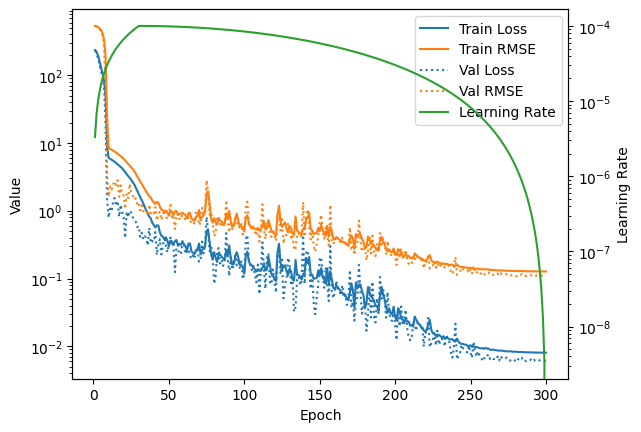

In [77]:
n = np.arange(1, EPOCHS+1)
metrics = {k: [float(i) for i in v] for k, v in train_metrics.items()}

fig, ax1 = plt.subplots()

ax1.plot(n, metrics["train_loss"], "C0", label="Train Loss")
ax1.plot(n, metrics["train_rmse"], "C1", label="Train RMSE")

ax1.plot(n, metrics["val_loss"], "C0:", label="Val Loss")
ax1.plot(n, metrics["val_rmse"], "C1:", label="Val RMSE")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Value")
ax1.set_yscale("log")

ax2 = ax1.twinx()

ax2.plot(n, metrics["lr"], "C2-", label="Learning Rate")
ax2.set_ylabel("Learning Rate")
ax2.set_yscale("log")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

# Comparison with Ground Truth

In [78]:
comparison_entity=["United Kingdom"]

In [79]:
model.eval()
data = []
for years in np.append(val_year, np.append(test_year, ood_test_year)):
    print(years)
    regional_data, global_data = load_tensor(comparison_entity, np.arange(years, years + SEQ_LEN))
    pred = model(global_data, regional_data[:, :-1])

    pred = pred[:, -1, 1:].cpu().detach().numpy()
    data.append(scaler.inverse_transform(pred))

data = np.vstack(data)
test_y = np.arange(2008, 2021)
pd.DataFrame(data, columns=df_global.columns[1:])

2009
2010
2011
2012


,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,99.320786,100.018623,10.959901,234.748993,71.319321,80.053238,48.336391,32693.333984,2.542084,460183.87500,41078.296875,292.119324,91208.132812,56.786736,-1.255908
1,99.414062,100.095085,12.132781,222.575470,69.057167,93.645615,52.791210,32390.996094,2.472085,452988.34375,40365.414062,292.638855,114182.820312,56.794659,-1.314812
2,99.372398,100.355461,13.426595,213.563416,62.952389,103.855949,55.442341,32138.763672,2.435647,450710.93750,43025.898438,293.168671,129197.382812,56.649792,-1.258546
3,99.488815,100.390572,14.692258,203.740860,53.717091,113.278297,57.379013,31275.023438,2.333866,448350.71875,42405.273438,293.339294,144098.765625,56.623764,-1.235186


In [80]:
regional_data = []

for year in test_y:
    year = int(year)

    regional_data.append(torch.tensor(entity_groups[comparison_entity[0]][years_index[year]]))


regional_data = torch.stack(regional_data)
gt = regional_data.numpy()
gt = scaler.inverse_transform(gt[:, 1:])
pd.DataFrame(gt, columns=df_global.columns[1:])

/tmp/ipykernel_1246/3359583700.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  regional_data.append(torch.tensor(entity_groups[comparison_entity[0]][years_index[year]]))


,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,100.0,100.0,2.79,310.50,52.49,21.85,19.317118,41451.902,3.24,515340.0269,47549.34863,281.0,243610.0,55.378051,-3.435973
1,100.0,100.0,3.38,278.73,69.10,25.25,25.289482,39040.560,3.18,466489.9902,38952.21103,281.0,243610.0,55.378051,-3.435973
2,100.0,100.0,3.67,290.59,62.14,26.18,23.308966,39540.008,3.23,482440.0024,39688.61497,281.0,243610.0,55.378051,-3.435973
3,100.0,100.0,4.44,260.88,68.98,35.20,28.537775,37007.074,2.96,445589.9963,42284.88449,281.0,243610.0,55.378051,-3.435973
4,100.0,100.0,4.77,249.25,70.40,41.24,30.934633,37292.910,2.99,467779.9988,42686.80005,281.0,243610.0,55.378051,-3.435973
5,100.0,100.0,6.02,231.56,70.61,53.21,34.841580,36881.977,2.88,453760.0098,43713.81412,281.0,243610.0,55.378051,-3.435973
6,100.0,100.0,7.36,206.94,63.75,64.52,38.265564,34583.770,2.64,415600.0061,47787.24130,281.0,243610.0,55.378051,-3.435973
7,100.0,100.0,8.61,182.43,70.34,82.57,45.598500,34890.320,2.61,401079.9866,45404.56777,281.0,243610.0,55.378051,-3.435973
8,100.0,100.0,8.60,181.56,71.73,82.99,46.009277,34296.684,2.53,380809.9976,41499.55570,281.0,243610.0,55.378051,-3.435973
9,100.0,100.0,9.70,165.91,70.34,98.85,50.489407,34098.812,2.45,367000.0000,40857.75558,281.0,243610.0,55.378051,-3.435973


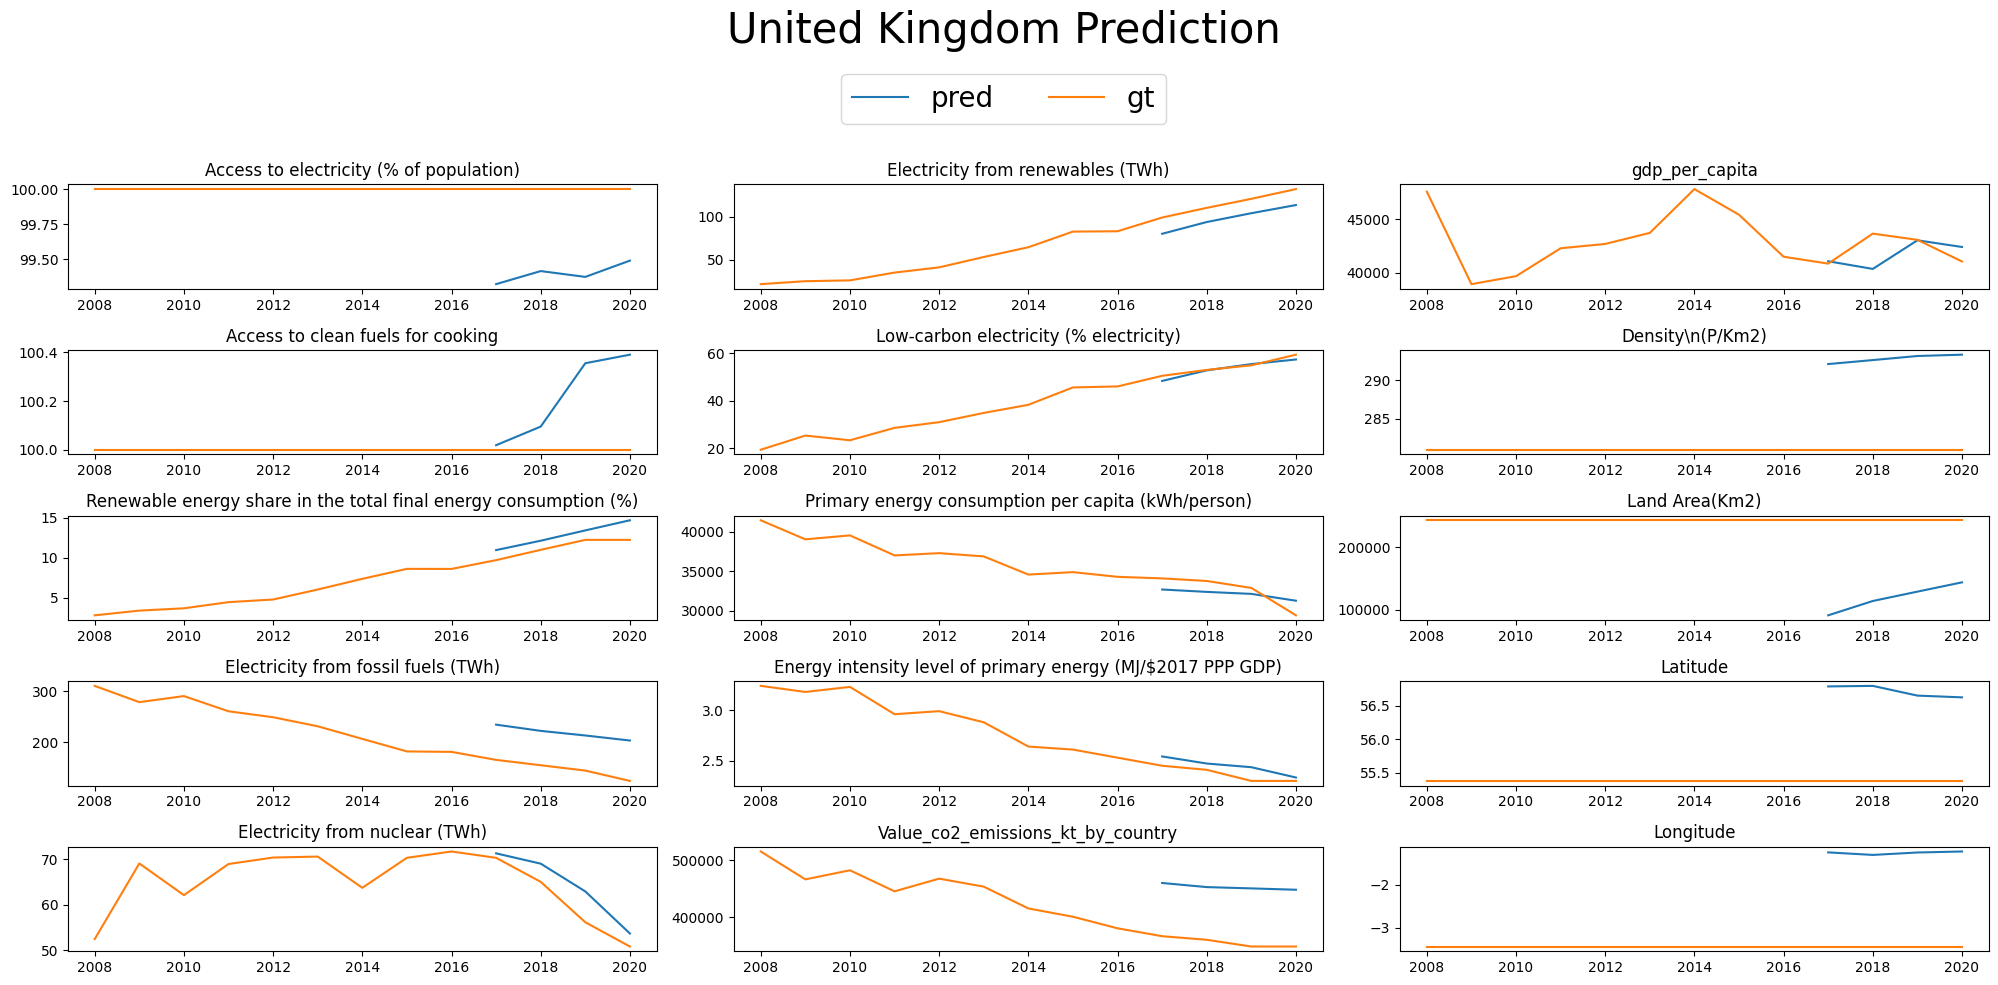

In [81]:
y = test_y[-4:]
cols = df_global.columns[1:]

fig, ax = plt.subplots(ncols=3, nrows=5, figsize=(20, 10))
for i, col in enumerate(cols):
    ax[i%5, i//5].plot(y, data[:, i], label="pred")
    ax[i%5, i//5].plot(test_y, gt[:, i], label="gt")
    ax[i%5, i//5].set_title(col, size=12)

fig.suptitle(comparison_entity[0] + " Prediction", size=30)

# Steal legend from one axis
handles, labels = ax[0, 0].get_legend_handles_labels()

# Put legend below suptitle
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),  # adjust vertically
    ncol=2,
    fontsize=20
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()